# 06 · Scalability
Throughput of the windowed scoring stage vs. worker count, measured on the
**Docker Compose cluster**.

Run the sweep first (produces `results/scalability.csv`):
```bash
bash scripts/run_scalability_sweep.sh          # macOS/Linux
powershell scripts\run_scalability_sweep.ps1   # Windows
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # project root, so `import src` works

In [2]:
import pandas as pd
from src.config import RESULTS
pd.read_csv(RESULTS / 'scalability.csv')

,workers,rows,time_s,throughput_rows_s
0,1,160359,35.65,4497
1,2,160359,20.57,7796
2,4,160359,17.68,9069
3,8,160359,18.04,8889


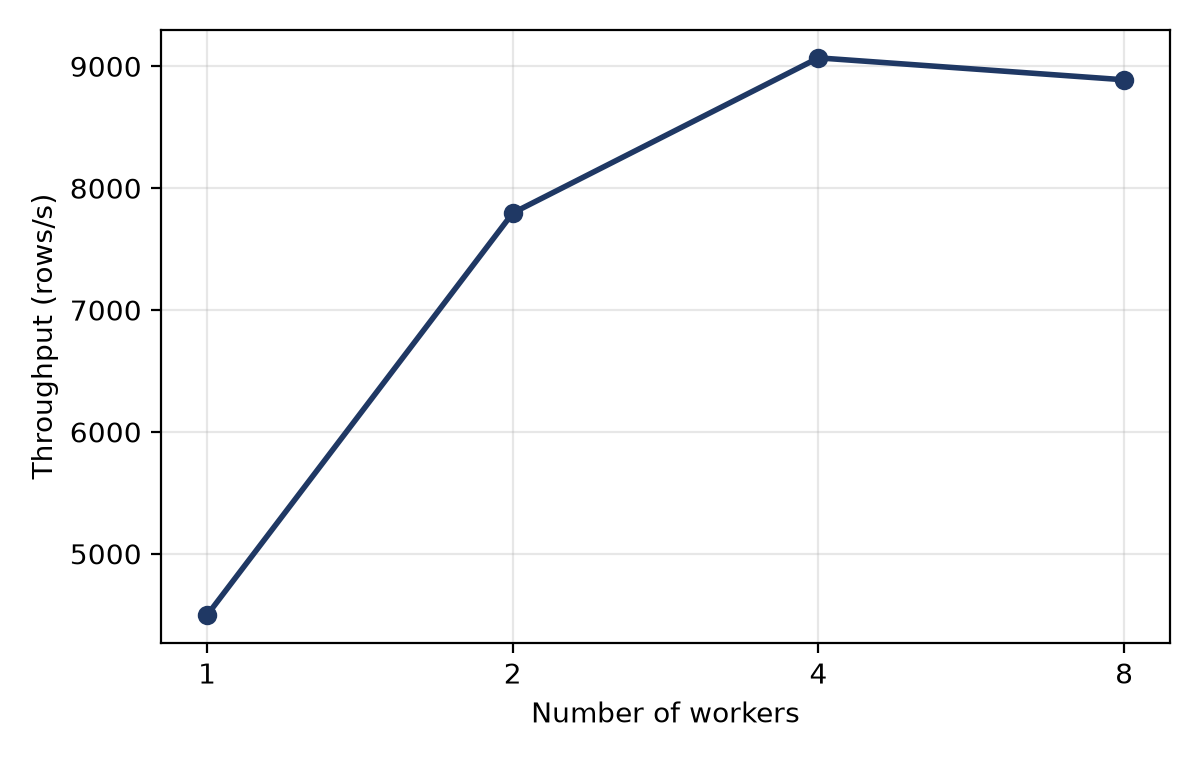

In [3]:
from src.plots import make_scalability_figure
from src.config import FIGURES
from IPython.display import Image, display
make_scalability_figure()
display(Image(filename=str(FIGURES / 'fig_scalability.png')))

**Reading:** near-linear scaling up to 4 workers (~2.3× speed-up), then a
plateau as the host's CPU cores saturate. Detection accuracy is hardware-
independent; throughput is the one figure that needs real parallel workers.